In [2]:
!pip install --upgrade pip
!pip install fvcore iopath matplotlib ninja imageio tqdm
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple, https://pypi.org/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple, https://pypi.org/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=c88a4febfa5c045ab3c4d259726f592d3ffcfb8bdf7984cf2e266d6c8b531033
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=a8f2262407f299ce4a2e45105edb920aac28b1d0c61cd4127bf070008cd4b5d8
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built

In [3]:
import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from tqdm import tqdm
from IPython.display import clear_output

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    RasterizationSettings,
    MeshRasterizer,
    SoftSilhouetteShader,
    BlendParams,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("当前运行设备:", device)
print("PyTorch 版本:", torch.__version__)
print("PyTorch3D 版本:", pytorch3d.__version__)


当前运行设备: cuda:0
PyTorch 版本: 2.10.0+cu128
PyTorch3D 版本: 0.7.9


In [5]:
os.makedirs("assets", exist_ok=True)
os.makedirs("output_meshes", exist_ok=True)
os.makedirs("data", exist_ok=True)

print("目录已准备完成。")


目录已准备完成。


In [6]:
obj_path = "cow.obj"

In [7]:
verts, faces, aux = load_obj(obj_path)

faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)

# 中心化与归一化
verts = verts - verts.mean(0)
verts = verts / verts.abs().max()

cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

print("Cow vertices:", verts.shape)
print("Cow faces:", faces_idx.shape)


/usr/local/lib/python3.12/site-packages/pytorch3d/io/obj_io.py:551: UserWarning: Mtl file does not exist: cow.mtl
  warnings.warn(f"Mtl file does not exist: {f}")


Cow vertices: torch.Size([2930, 3])
Cow faces: torch.Size([5856, 3])


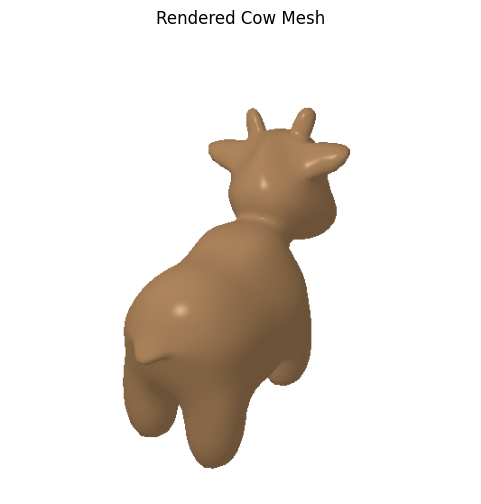

Saved single render to outputs/cow_render.png
Rendered frame 1/36
Rendered frame 2/36
Rendered frame 3/36
Rendered frame 4/36
Rendered frame 5/36
Rendered frame 6/36
Rendered frame 7/36
Rendered frame 8/36
Rendered frame 9/36
Rendered frame 10/36
Rendered frame 11/36
Rendered frame 12/36
Rendered frame 13/36
Rendered frame 14/36
Rendered frame 15/36
Rendered frame 16/36
Rendered frame 17/36
Rendered frame 18/36
Rendered frame 19/36
Rendered frame 20/36
Rendered frame 21/36
Rendered frame 22/36
Rendered frame 23/36
Rendered frame 24/36
Rendered frame 25/36
Rendered frame 26/36
Rendered frame 27/36
Rendered frame 28/36
Rendered frame 29/36
Rendered frame 30/36
Rendered frame 31/36
Rendered frame 32/36
Rendered frame 33/36
Rendered frame 34/36
Rendered frame 35/36
Rendered frame 36/36
Saved rotating GIF to outputs/cow_rotation.gif
Saved front view to outputs/cow_front.png
Saved side view to outputs/cow_side.png
Saved top view to outputs/cow_top.png
Saved diagonal view to outputs/cow_diago

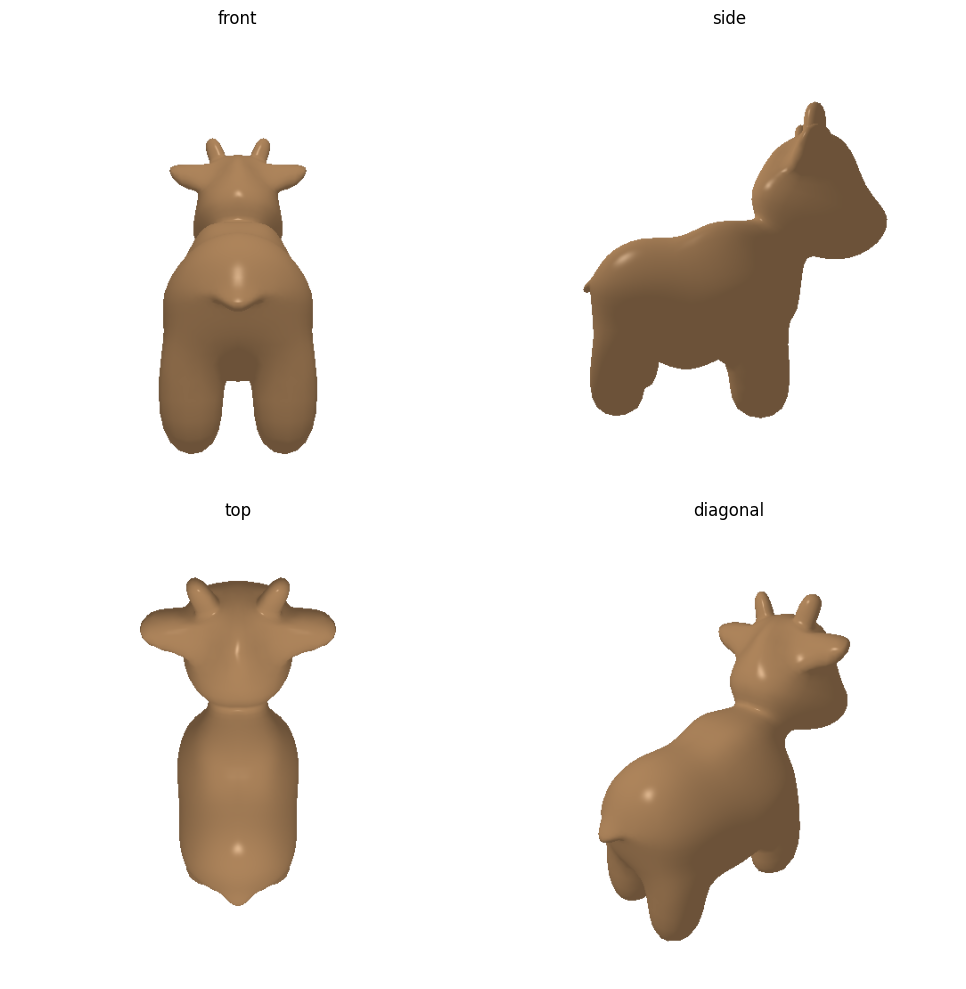

Saved view comparison to outputs/cow_views_compare.png
Saved light result to outputs/light_front.png
Saved light result to outputs/light_top.png
Saved light result to outputs/light_left.png
Saved light result to outputs/light_right.png


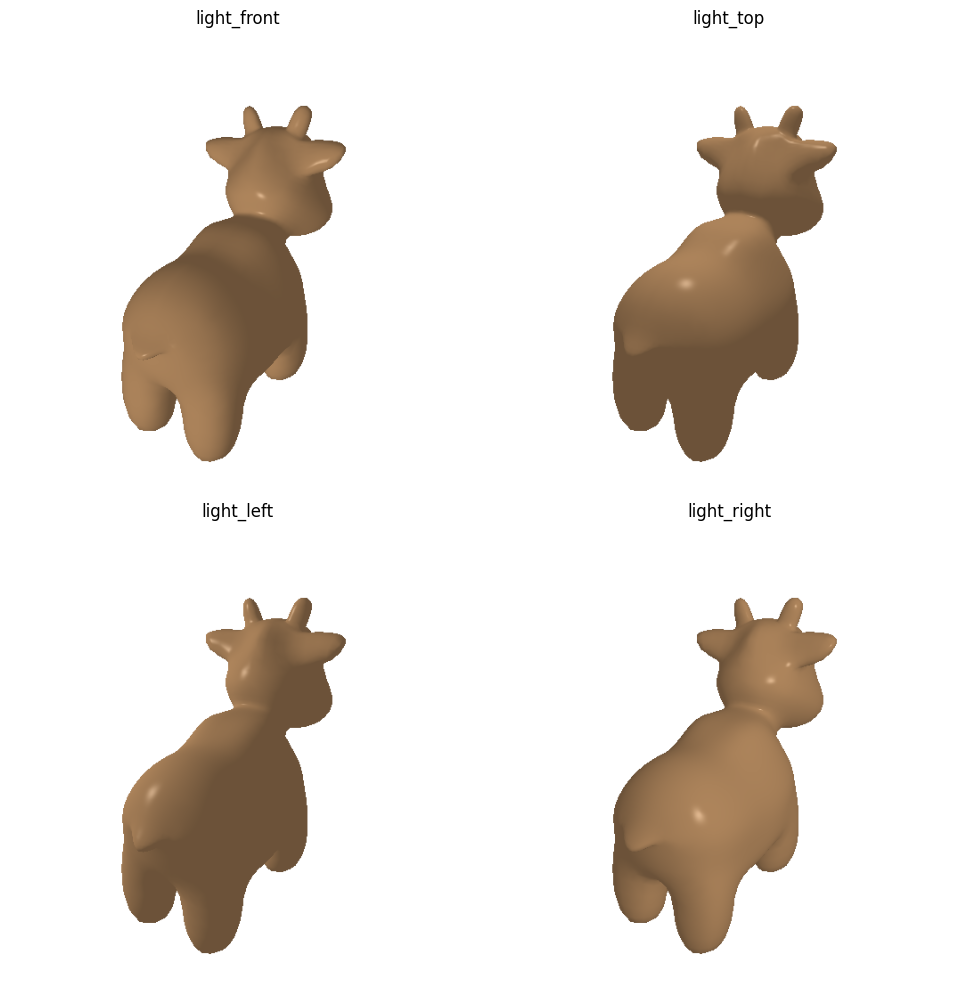

Saved light comparison to outputs/cow_lights_compare.png

Experiment 6 finished successfully.
Generated files:
1. outputs/cow_render.png
2. outputs/cow_rotation.gif
3. outputs/cow_front.png
4. outputs/cow_side.png
5. outputs/cow_top.png
6. outputs/cow_diagonal.png
7. outputs/cow_views_compare.png
8. outputs/cow_lights_compare.png


In [8]:
# ============================================================
# Experiment 6: PyTorch3D Mesh Rendering
# ============================================================

import os
import math
import torch
import imageio
import matplotlib.pyplot as plt

from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras,
    look_at_view_transform,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    PointLights,
    TexturesVertex,
    BlendParams,
)


# ============================================================
# 1. 给 cow mesh 添加顶点颜色
# ============================================================

# 如果没有 mtl 材质文件，就手动给模型加一个颜色
# verts_rgb 的 shape 是 [1, V, 3]
# 这里使用浅棕色，让 cow 看起来更清楚
verts_rgb = torch.ones_like(verts)[None]  # [1, V, 3]
verts_rgb[:, :, 0] = 0.85
verts_rgb[:, :, 1] = 0.65
verts_rgb[:, :, 2] = 0.45

textures = TexturesVertex(verts_features=verts_rgb)
cow_mesh.textures = textures


# ============================================================
# 2. 设置渲染参数
# ============================================================

image_size = 512

raster_settings = RasterizationSettings(
    image_size=image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

blend_params = BlendParams(
    background_color=(1.0, 1.0, 1.0),
)


# ============================================================
# 3. 设置相机、光照、渲染器
# ============================================================

# 相机位置
# dist 越大，相机离物体越远
# elev 是俯仰角
# azim 是水平旋转角
R, T = look_at_view_transform(
    dist=2.7,
    elev=20.0,
    azim=30.0,
    device=device,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

lights = PointLights(
    device=device,
    location=[[0.0, 2.0, 2.0]],
)

renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=cameras,
        lights=lights,
        blend_params=blend_params,
    ),
)


# ============================================================
# 4. 渲染单张图片
# ============================================================

images = renderer(cow_mesh)

# images shape: [1, H, W, 4]
# 前三个通道是 RGB，最后一个是 alpha
image = images[0, ..., :3].detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Rendered Cow Mesh")

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/cow_render.png", bbox_inches="tight", pad_inches=0)
plt.show()

print("Saved single render to outputs/cow_render.png")


# ============================================================
# 5. 多视角旋转渲染 GIF
# ============================================================

gif_frames = []

num_frames = 36

for i in range(num_frames):
    azim = 360.0 * i / num_frames

    R, T = look_at_view_transform(
        dist=2.7,
        elev=20.0,
        azim=azim,
        device=device,
    )

    cameras = FoVPerspectiveCameras(
        device=device,
        R=R,
        T=T,
    )

    lights = PointLights(
        device=device,
        location=[[0.0, 2.0, 2.0]],
    )

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            cameras=cameras,
            raster_settings=raster_settings,
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras,
            lights=lights,
            blend_params=blend_params,
        ),
    )

    rendered_image = renderer(cow_mesh)
    frame = rendered_image[0, ..., :3].detach().cpu().numpy()

    # 转成 uint8，方便 imageio 保存 GIF
    frame_uint8 = (frame * 255).clip(0, 255).astype("uint8")
    gif_frames.append(frame_uint8)

    print(f"Rendered frame {i + 1}/{num_frames}")


gif_path = "outputs/cow_rotation.gif"
imageio.mimsave(gif_path, gif_frames, fps=12)

print(f"Saved rotating GIF to {gif_path}")


# ============================================================
# 6. 渲染不同相机角度对比图
# ============================================================

view_settings = [
    {"name": "front", "dist": 2.7, "elev": 0.0, "azim": 0.0},
    {"name": "side", "dist": 2.7, "elev": 0.0, "azim": 90.0},
    {"name": "top", "dist": 2.7, "elev": 70.0, "azim": 0.0},
    {"name": "diagonal", "dist": 2.7, "elev": 25.0, "azim": 45.0},
]

view_images = []

for view in view_settings:
    R, T = look_at_view_transform(
        dist=view["dist"],
        elev=view["elev"],
        azim=view["azim"],
        device=device,
    )

    cameras = FoVPerspectiveCameras(
        device=device,
        R=R,
        T=T,
    )

    lights = PointLights(
        device=device,
        location=[[0.0, 2.0, 2.0]],
    )

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            cameras=cameras,
            raster_settings=raster_settings,
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras,
            lights=lights,
            blend_params=blend_params,
        ),
    )

    rendered_image = renderer(cow_mesh)
    image_np = rendered_image[0, ..., :3].detach().cpu().numpy()
    view_images.append((view["name"], image_np))

    save_path = f"outputs/cow_{view['name']}.png"

    plt.figure(figsize=(5, 5))
    plt.imshow(image_np)
    plt.axis("off")
    plt.title(view["name"])
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

    print(f"Saved {view['name']} view to {save_path}")


# 合成一张 2x2 对比图
plt.figure(figsize=(10, 10))

for idx, (name, img) in enumerate(view_images):
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)

plt.tight_layout()
plt.savefig("outputs/cow_views_compare.png", bbox_inches="tight")
plt.show()

print("Saved view comparison to outputs/cow_views_compare.png")


# ============================================================
# 7. 改变光照位置并渲染对比
# ============================================================

light_settings = [
    {"name": "light_front", "location": [[0.0, 0.0, 3.0]]},
    {"name": "light_top", "location": [[0.0, 3.0, 0.0]]},
    {"name": "light_left", "location": [[-3.0, 2.0, 2.0]]},
    {"name": "light_right", "location": [[3.0, 2.0, 2.0]]},
]

light_images = []

R, T = look_at_view_transform(
    dist=2.7,
    elev=20.0,
    azim=30.0,
    device=device,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

for light_setting in light_settings:
    lights = PointLights(
        device=device,
        location=light_setting["location"],
    )

    renderer = MeshRenderer(
        rasterizer=MeshRasterizer(
            cameras=cameras,
            raster_settings=raster_settings,
        ),
        shader=SoftPhongShader(
            device=device,
            cameras=cameras,
            lights=lights,
            blend_params=blend_params,
        ),
    )

    rendered_image = renderer(cow_mesh)
    image_np = rendered_image[0, ..., :3].detach().cpu().numpy()
    light_images.append((light_setting["name"], image_np))

    save_path = f"outputs/{light_setting['name']}.png"

    plt.figure(figsize=(5, 5))
    plt.imshow(image_np)
    plt.axis("off")
    plt.title(light_setting["name"])
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()

    print(f"Saved light result to {save_path}")


plt.figure(figsize=(10, 10))

for idx, (name, img) in enumerate(light_images):
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)

plt.tight_layout()
plt.savefig("outputs/cow_lights_compare.png", bbox_inches="tight")
plt.show()

print("Saved light comparison to outputs/cow_lights_compare.png")


# ============================================================
# 8. 输出实验结果说明
# ============================================================

print("")
print("Experiment 6 finished successfully.")
print("Generated files:")
print("1. outputs/cow_render.png")
print("2. outputs/cow_rotation.gif")
print("3. outputs/cow_front.png")
print("4. outputs/cow_side.png")
print("5. outputs/cow_top.png")
print("6. outputs/cow_diagonal.png")
print("7. outputs/cow_views_compare.png")
print("8. outputs/cow_lights_compare.png")


In [12]:
import os
print(os.getcwd())
print(os.listdir())


/mnt/workspace/Untitled Folder
['.ipynb_checkpoints', 'assets', 'cow.obj', 'data', 'new-workspace.jupyterlab-workspace', 'output_meshes', 'outputs', '未命名.ipynb']
